# GraphRAG evaluation against six baselines

This notebook evaluates the **saved predictions** from the same pipelines as
`poster_method_comparison.ipynb`. GraphRAG is the method of interest; SapBERT,
BioLORD + context, AI context + BioLORD, BM25, BM25 + fuzzy, and Jaccard are baselines.
ICD9 and ICD10 are evaluated separately throughout. No model or service calls are made.

**Reading order:** settings → label/data audit → metrics → separate dataset results →
GraphRAG retrieval/filter/reranking diagnostics → worked examples → exports.

Run all cells using the project Python environment. Required packages: pandas, numpy,
pyarrow, matplotlib, IPython, and Jupyter/ipykernel. Inputs are the two dataset-specific
checkpoints, source CSVs, and optional GraphRAG JSONL logs under `data/` (or
`CONCEPT_NORM_DATA_DIR`). Figures are saved as PNG and SVG; numeric results as CSV.

The implementation lives in
[`notebook_evaluation.py`](src/concept_normalisation/notebook_evaluation.py).
This notebook keeps the settings, evaluation sequence, explanations, and results visible;
the module handles data checks, metric calculations, plotting, and trace rendering.
Install the project with `pip install -e ".[evaluation]"` before running the notebook.


In [1]:
from IPython.display import display
from concept_normalisation import notebook_evaluation as evaluation

ROOT = evaluation.find_repository_root()
DATA_DIR = evaluation.resolve_data_directory(ROOT)
OUTPUT = DATA_DIR / "output" / "graphrag_baseline_evaluation"
SPECS = evaluation.dataset_specs(DATA_DIR)

# Edit the evaluation settings here.
KS = [1, 2, 3, 4, 5]
MRR_DEPTH = 5
PRIMARY_VIEW = "unique query"  # Alternatively: "row".

evaluation.configure_display()
print("Inputs:", DATA_DIR)
print("Exports:", OUTPUT)

Inputs: C:\repos\concept-normalisation\data
Exports: C:\repos\concept-normalisation\data\output\graphrag_baseline_evaluation


## 1. Define the evaluation carefully

For a query, let **G** be its set of valid SNOMED targets and **Pₖ** the first K
distinct predicted IDs in the method's saved order.

| Metric | Per-query definition | Interpretation |
|---|---|---|
| Recall@K | `len(set(Pₖ) & G) / len(G)` | Fraction of all labelled targets recovered |
| Top-1 Accuracy | `1` if the first prediction is in G, else `0` | Whether the first answer is acceptable |
| MRR@5 | `1 / rank` of the first valid target within five predictions, else `0` | How early an acceptable answer appears |

All scores use **exact SNOMED ID equality**. We do not give credit for ancestors or
descendants. For singleton labels, Recall@1 equals Top-1 Accuracy; for multiple labels
it generally does not. Hit@K (any target found) is a different metric from set recall.

The mapping direction matters: many SNOMED targets may map to one ICD code, but the
reverse ICD→SNOMED evaluation has a **set of valid targets**. The audit below measures
the actual set sizes instead of assuming cardinality from the dataset name. With 16
targets and only five predictions, even a perfect list has Recall@5 ≤ 5/16.

We retain each method's saved order, remove repeated IDs before computing concept ranks,
and never sort the LLM's output by its copied retrieval scores. Empty results and missing
row predictions score zero on the common labelled cohort; their coverage is reported.
An entirely absent method column is reported as unavailable. Unlabelled rows are excluded
for every method. Malformed results fail loudly instead of being silently counted as misses.

Two averaging views are reported: **unique query** averages within each (diagnosis text,
ICD code), then gives each such query equal weight; **row** gives every checkpoint row
equal weight. These are descriptive results for these datasets, not independent-patient
estimates or evidence of statistical significance.

In [2]:
# A small worked example: one of two targets is found at rank 2.
example_scores = evaluation.score_ids(
    ids=["other_concept", "target_a"],
    gold={"target_a", "target_b"},
    ks=[1, 2],
    depth=MRR_DEPTH,
)
display(example_scores)  # Top-1 = 0, MRR = 0.5, Recall@2 = 0.5.

{'Top-1 Accuracy': 0.0, 'MRR@5': 0.5, 'Recall@1': 0.0, 'Recall@2': 0.5}

## 2. Audit both datasets before comparing methods

The truth join checks that each ICD code has an unambiguous target set and that the
checkpoint agrees with the source CSV. Source identifiers are read as strings to preserve
large SNOMED IDs. Exact duplicate source rows are counted, not silently removed.

The existing ICD9 checkpoint has legacy numeric-conversion artifacts: for example,
`564.00` became `564.0` and SNOMED `66657009` became `66657009.0`. We restore the exact
ICD code from the source CSV using (diagnosis ID, stay ID, diagnosis string), validate the
join as many-to-one, and report how many keys changed. Integral `.0` SNOMED strings are
repaired only below the exact-integer float limit; potentially rounded large IDs fail.

In [3]:
datasets, audit, coverage = evaluation.load_datasets(SPECS, MRR_DEPTH)
display(audit)
display(coverage)

,dataset,source rows,checkpoint rows,restored ICD keys,exact duplicate source rows,excluded unlabelled rows,labelled rows,unique queries,singleton queries,multi-target queries,min targets,max targets
0,ICD10,9637,9637,0,8909,0,9637,29,0,29,3,16
1,ICD9,6356,6356,701,4335,220,6136,49,49,0,1,1
2,snomed_challenge_50,158,158,0,103,0,158,50,46,4,1,3


,dataset,method,status,labelled rows,missing predictions,empty predictions,min distinct predictions,max distinct predictions,rows with fewer than 5
0,ICD10,SapBERT,available,9637,0,0,1,5,9597
1,ICD10,BioLORD + context,available,9637,0,0,1,5,9433
2,ICD10,AI context + BioLORD,available,9637,0,0,2,5,9340
3,ICD10,BM25,available,9637,0,0,2,5,9111
4,ICD10,BM25 + fuzzy,available,9637,0,0,2,5,9440
5,ICD10,Jaccard,available,9637,0,0,3,5,6841
6,ICD10,GraphRAG,available,9637,0,0,5,5,0
7,ICD9,SapBERT,available,6136,0,0,1,4,6136
8,ICD9,BioLORD + context,available,6136,0,0,1,5,6123
9,ICD9,AI context + BioLORD,available,6136,0,0,1,5,6123


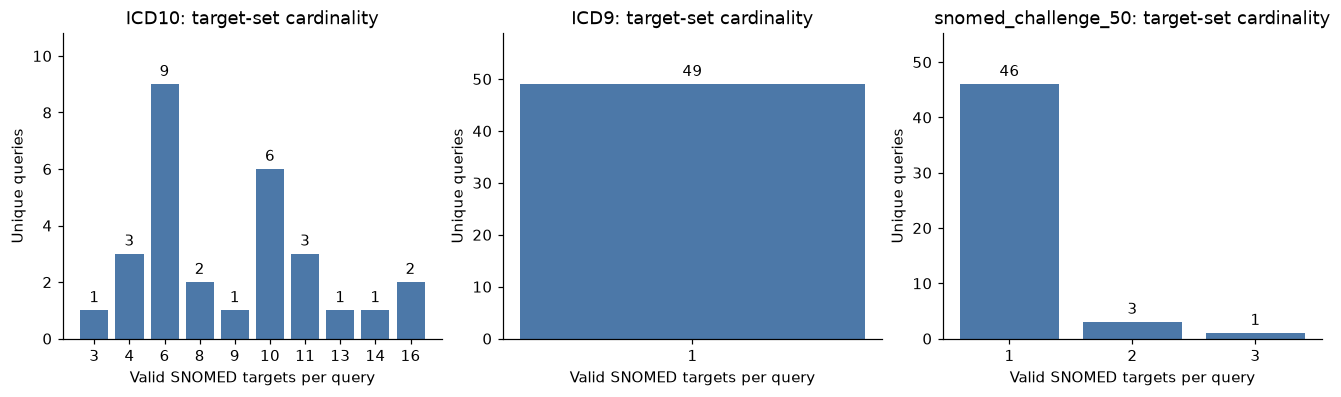

In [4]:
evaluation.plot_target_cardinality(datasets, OUTPUT)

## 3. Compute comparable scores

Every available method uses the same labelled rows within a dataset. MRR is truncated
at the shared saved depth; shorter lists are not padded with invented candidates.
The detailed table retains row IDs and query keys for paired comparisons and error analysis.

In [5]:
per_row, per_query, scores = evaluation.evaluate_methods(
    datasets, ks=KS, mrr_depth=MRR_DEPTH,
)

## 4a. ICD9: GraphRAG versus the baselines

Both averaging views are shown below. The chart uses the selected primary view and
highlights GraphRAG in red. Values are on a 0–1 scale, including MRR.

n  Top-1 Accuracy   MRR@5  Recall@1  \
view         method                                                         
unique query SapBERT                 49          0.2449  0.2993    0.2449   
             BioLORD + context       49          0.1633  0.2014    0.1633   
             AI context + BioLORD    49          0.2449  0.2806    0.2449   
             BM25                    49          0.2245  0.2857    0.2245   
             BM25 + fuzzy            49          0.1837  0.2286    0.1837   
             Jaccard                 49          0.0612  0.1037    0.0612   
             GraphRAG                49          0.3265  0.3844    0.3265   
row          SapBERT               6136          0.2052  0.2312    0.2052   
             BioLORD + context     6136          0.0846  0.1336    0.0846   
             AI context + BioLORD  6136          0.2578  0.2807    0.2578   
             BM25                  6136          0.1998  0.2300    0.1998   
             BM25 + fuzzy          6136          0.0991  0.1320    0.0991   
             Jaccard               6136          0.0106  0.0625    0.0106   
             GraphRAG              6136          0.3215  0.4060    0.3215   

                                   Recall@2  Recall@3  Recall@4  Recall@5  
view         method                                                        
unique query SapBERT                 0.3265    0.3673    0.3673    0.3673  
             BioLORD + context       0.2041    0.2449    0.2449    0.2653  
             AI context + BioLORD    0.2653    0.3265    0.3469    0.3469  
             BM25                    0.2857    0.3469    0.3878    0.3878  
             BM25 + fuzzy            0.2041    0.2653    0.3061    0.3265  
             Jaccard                 0.0612    0.1429    0.2041    0.2041  
             GraphRAG                0.4082    0.4286    0.4694    0.4694  
row          SapBERT                 0.2539    0.2588    0.2588    0.2588  
             BioLORD + context       0.1437    0.2009    0.2009    0.2027  
             AI context + BioLORD    0.2705    0.3124    0.3228    0.3228  
             BM25                    0.2283    0.2415    0.2878    0.2878  
             BM25 + fuzzy            0.0993    0.1846    0.2018    0.2021  
             Jaccard                 0.0106    0.0680    0.1992    0.1992  
             GraphRAG                0.4438    0.4731    0.5272    0.5272

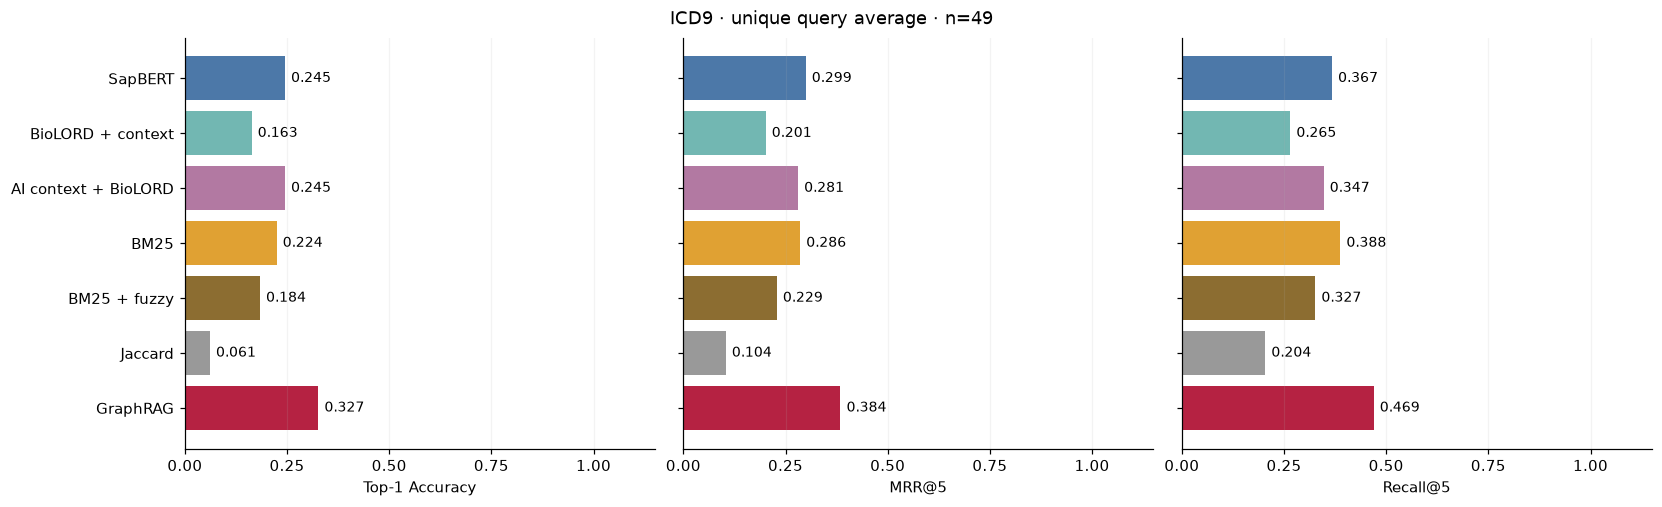

In [6]:
display(evaluation.dataset_score_table(scores, "ICD9", KS, MRR_DEPTH))
evaluation.plot_method_comparison(
    scores, "ICD9", ks=KS, mrr_depth=MRR_DEPTH,
    view=PRIMARY_VIEW, output_dir=OUTPUT,
)

## 4b. ICD10: GraphRAG versus the baselines

Both averaging views are shown below. The chart uses the selected primary view and
highlights GraphRAG in red. Values are on a 0–1 scale, including MRR.

n  Top-1 Accuracy   MRR@5  Recall@1  \
view         method                                                         
unique query SapBERT                 29          0.3793  0.4483    0.0485   
             BioLORD + context       29          0.4483  0.5374    0.0695   
             AI context + BioLORD    29          0.4828  0.5805    0.0702   
             BM25                    29          0.1379  0.2586    0.0157   
             BM25 + fuzzy            29          0.1034  0.1897    0.0135   
             Jaccard                 29          0.0000  0.0690    0.0000   
             GraphRAG                29          0.5862  0.6247    0.0739   
row          SapBERT               9637          0.9011  0.9227    0.0626   
             BioLORD + context     9637          0.1469  0.5504    0.0193   
             AI context + BioLORD  9637          0.6525  0.8057    0.0496   
             BM25                  9637          0.5790  0.6045    0.0382   
             BM25 + fuzzy          9637          0.0378  0.3205    0.0044   
             Jaccard               9637          0.0000  0.0166    0.0000   
             GraphRAG              9637          0.9517  0.9557    0.0695   

                                   Recall@2  Recall@3  Recall@4  Recall@5  
view         method                                                        
unique query SapBERT                 0.0620    0.0939    0.0939    0.0939  
             BioLORD + context       0.0916    0.0959    0.0986    0.0986  
             AI context + BioLORD    0.0962    0.1109    0.1201    0.1201  
             BM25                    0.0510    0.0625    0.0625    0.0625  
             BM25 + fuzzy            0.0337    0.0337    0.0337    0.0337  
             Jaccard                 0.0069    0.0161    0.0161    0.0161  
             GraphRAG                0.0848    0.1256    0.1441    0.1671  
row          SapBERT                 0.0689    0.0750    0.0750    0.0750  
             BioLORD + context       0.0737    0.0754    0.0758    0.0758  
             AI context + BioLORD    0.0750    0.0763    0.0790    0.0790  
             BM25                    0.0461    0.0487    0.0487    0.0487  
             BM25 + fuzzy            0.0416    0.0416    0.0416    0.0416  
             Jaccard                 0.0024    0.0036    0.0036    0.0036  
             GraphRAG                0.0740    0.0815    0.0882    0.0904

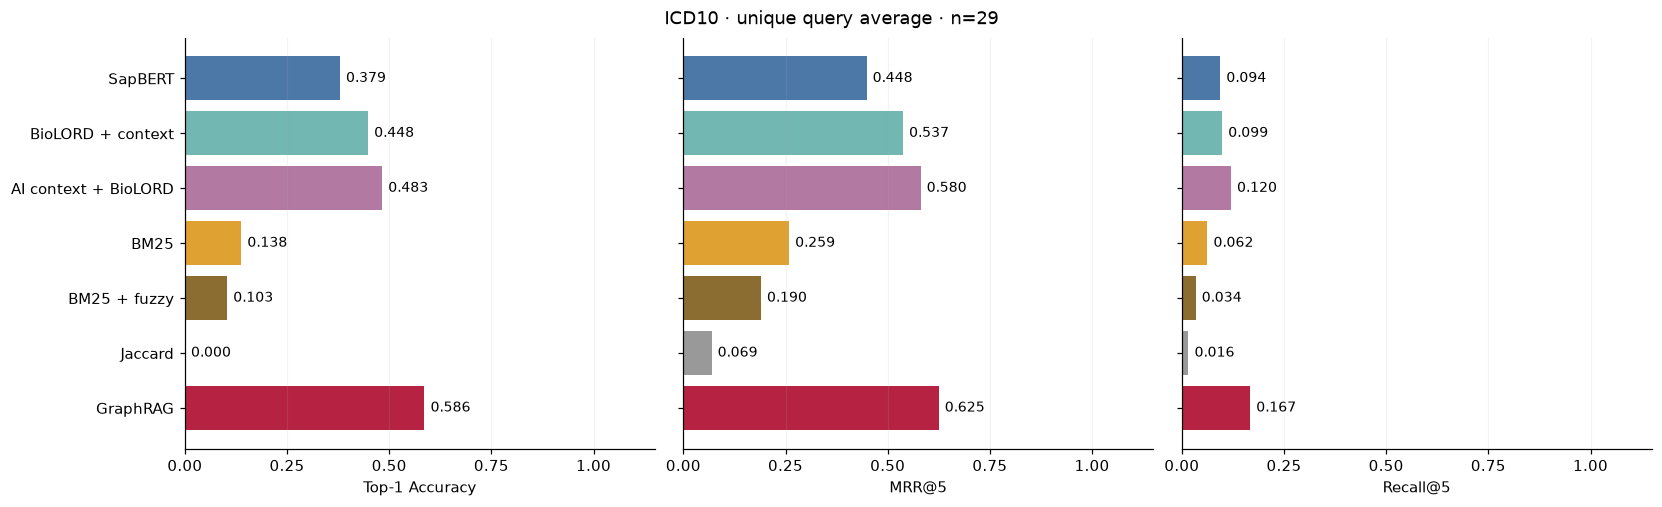

In [7]:
display(evaluation.dataset_score_table(scores, "ICD10", KS, MRR_DEPTH))
evaluation.plot_method_comparison(
    scores, "ICD10", ks=KS, mrr_depth=MRR_DEPTH,
    view=PRIMARY_VIEW, output_dir=OUTPUT,
)

n  Top-1 Accuracy   MRR@5  Recall@1  \
view         method                                                        
unique query SapBERT                50          0.4000  0.4533    0.3900   
             BioLORD + context      50          0.3600  0.4173    0.3500   
             AI context + BioLORD   50          0.3200  0.3950    0.3200   
             BM25                   50          0.4000  0.4207    0.3900   
             BM25 + fuzzy           50          0.3600  0.3873    0.3500   
             Jaccard                50          0.3600  0.3967    0.3500   
             GraphRAG               50          0.4800  0.5067    0.4700   
row          SapBERT               158          0.3165  0.3608    0.2690   
             BioLORD + context     158          0.2468  0.3088    0.1994   
             AI context + BioLORD  158          0.1835  0.2948    0.1835   
             BM25                  158          0.3228  0.3679    0.2753   
             BM25 + fuzzy          158          0.2975  0.3283    0.2500   
             Jaccard               158          0.2658  0.3138    0.2184   
             GraphRAG              158          0.3544  0.3797    0.3070   

                                   Recall@2  Recall@3  Recall@4  Recall@5  
view         method                                                        
unique query SapBERT                 0.4600    0.5000    0.5000    0.5000  
             BioLORD + context       0.4200    0.4500    0.4767    0.4967  
             AI context + BioLORD    0.4200    0.4700    0.4900    0.4900  
             BM25                    0.4000    0.4200    0.4200    0.4400  
             BM25 + fuzzy            0.3600    0.4000    0.4000    0.4200  
             Jaccard                 0.3800    0.4000    0.4400    0.4400  
             GraphRAG                0.5100    0.5400    0.5400    0.5400  
row          SapBERT                 0.3259    0.3449    0.3449    0.3449  
             BioLORD + context       0.3101    0.3544    0.3692    0.3755  
             AI context + BioLORD    0.3165    0.3892    0.4082    0.4082  
             BM25                    0.2943    0.3006    0.3006    0.4209  
             BM25 + fuzzy            0.2690    0.3006    0.3006    0.3070  
             Jaccard                 0.2563    0.3006    0.3196    0.3196  
             GraphRAG                0.3449    0.4114    0.4114    0.4114

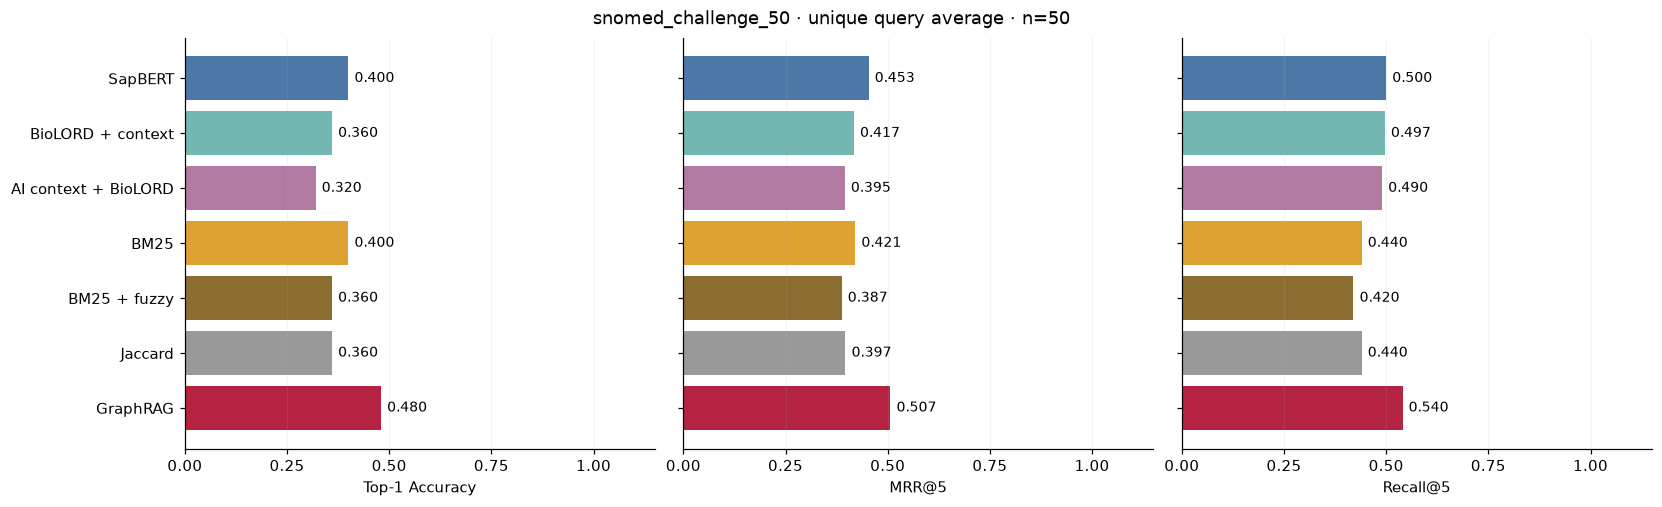

In [8]:
display(evaluation.dataset_score_table(scores, "snomed_challenge_50", KS, MRR_DEPTH))
evaluation.plot_method_comparison(
    scores, "snomed_challenge_50", ks=KS, mrr_depth=MRR_DEPTH,
    view=PRIMARY_VIEW, output_dir=OUTPUT,
)

## 5. Recall curves and paired differences

The dashed ceiling is the mean of `min(K, |G|) / |G|` for each dataset: set recall is
structurally constrained by target-set size. It is not a method's measured score.
The difference table subtracts each baseline from GraphRAG on the same queries.
Positive differences favour GraphRAG. We make no significance claim from these small,
repeated datasets.

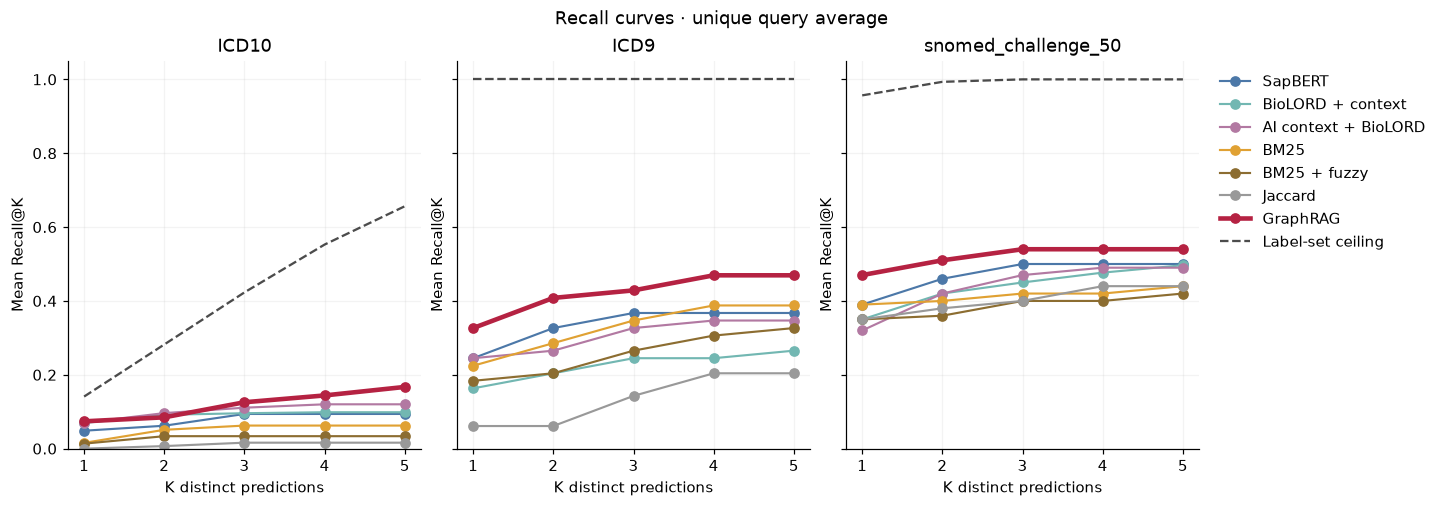

,dataset,baseline,Top-1 Accuracy,MRR@5,Recall@5
0,ICD10,SapBERT,0.2069,0.1764,0.0732
1,ICD10,BioLORD + context,0.1379,0.0874,0.0685
2,ICD10,AI context + BioLORD,0.1034,0.0443,0.0470
3,ICD10,BM25,0.4483,0.3661,0.1046
4,ICD10,BM25 + fuzzy,0.4828,0.4351,0.1334
5,ICD10,Jaccard,0.5862,0.5557,0.1510
6,ICD9,SapBERT,0.0816,0.0850,0.1020
7,ICD9,BioLORD + context,0.1633,0.1830,0.2041
8,ICD9,AI context + BioLORD,0.0816,0.1037,0.1224
9,ICD9,BM25,0.1020,0.0986,0.0816


In [9]:
evaluation.plot_recall_curves(datasets, scores, KS, PRIMARY_VIEW, OUTPUT)

deltas = evaluation.baseline_differences(scores, KS, MRR_DEPTH, PRIMARY_VIEW)
display(deltas.round(4))

## 6. How GraphRAG makes its selection

The implementation in `graphrag_matcher.py` and `graphrag_queries.py` follows these steps:

1. **Clean the diagnosis.** Replace `/` with `or`, collapse whitespace, and trim.
2. **Retrieve twice.** Base and enriched vector indexes each participate in a hybrid
   vector/full-text retrieval. Both use the same full-text index.
3. **Attach graph evidence.** Fetch parents, grandparents, children, finding sites,
   morphologies, causes, clinical course, and interpreted entities. These are context,
   not additional selectable candidates.
4. **Fuse by SCTID.** Keep one record per candidate, retaining base/enriched scores and
   provenance. The fused score is the maximum of the two available scores. The current
   implementation preserves insertion order (base first, then enriched-only entries);
   **it does not sort the fused list by score**.
5. **Filter.** Keep candidates with score ≥ the configured threshold (also keep missing
   scores). The log records the actual surviving list.
6. **LLM selection/reranking.** The prompt asks the LLM to rank only surviving candidates
   using the diagnosis and graph evidence, copy their original scores, and provide brief
   reasons. The final list order defines rank. The copied score is not a probability
   or an LLM confidence value. The matcher truncates to its configured maximum.

The current prompt asks for candidate membership but the matcher does not enforce it.
We therefore explicitly audit final IDs against the supplied pool. Reported reasons are
the model's saved explanations, not proof of its internal reasoning.

**Historical limits:** logs contain fused candidates, survivors, matches, and timestamps,
but not a run ID, threshold, model version, raw per-channel ranks, or full prompt.
We select the latest log whose ordered final IDs match the checkpoint for that cleaned
query. This provides a consistency check, not proof of identical run provenance.
Unmatched/ambiguous queries are reported and excluded only from stage diagnostics,
never from the main method comparison. No historical settings are invented.

In [10]:
trace_records, trace_coverage = evaluation.load_traces(datasets, SPECS)

display(
    trace_coverage.groupby(["dataset", "status"]).agg(
        queries=("query_key", "size"),
        rows=("row_count", "sum"),
    )
)

queries  rows
dataset             status                          
ICD10               matched final IDs       28  7237
                    no matching log          1  2400
ICD9                matched final IDs       45  5350
                    no matching log          4   786
snomed_challenge_50 matched final IDs       50   158

## 7. Locate GraphRAG's successes and losses

These diagnostics give each matched unique query equal weight. Pool recall uses **all**
IDs in the named pool, so it is not Recall@K for a fixed K and should not be compared as
an equal-budget baseline. The stage plot asks whether **any** valid target survives each
step. The outcome chart separates retrieval misses, filtering losses, selection losses,
lower-ranked successes, and correct first answers.

queries  mean_candidates  \
dataset             stage                                       
ICD10               Retrieved union       28          13.8571   
                    After filter          28          13.8571   
                    Final list            28           5.0000   
                    Final top-1           28           1.0000   
ICD9                Retrieved union       45          14.1333   
                    After filter          45          14.0444   
                    Final list            45           5.0000   
                    Final top-1           45           1.0000   
snomed_challenge_50 Retrieved union       50          11.5800   
                    After filter          50          11.3000   
                    Final list            50           4.9600   
                    Final top-1           50           1.0000   

                                     any_target_rate  mean_pool_recall  
dataset             stage                                               
ICD10               Retrieved union           0.7857            0.2724  
                    After filter              0.7857            0.2724  
                    Final list                0.7143            0.1708  
                    Final top-1               0.5714            0.0743  
ICD9                Retrieved union           0.4222            0.4222  
                    After filter              0.4222            0.4222  
                    Final list                0.4222            0.4222  
                    Final top-1               0.2889            0.2889  
snomed_challenge_50 Retrieved union           0.5400            0.5400  
                    After filter              0.5400            0.5400  
                    Final list                0.5400            0.5400  
                    Final top-1               0.4800            0.4700

,outside_pool_count,filter_ids_not_retrieved
dataset,,
ICD10,0,0
ICD9,0,0
snomed_challenge_50,0,0


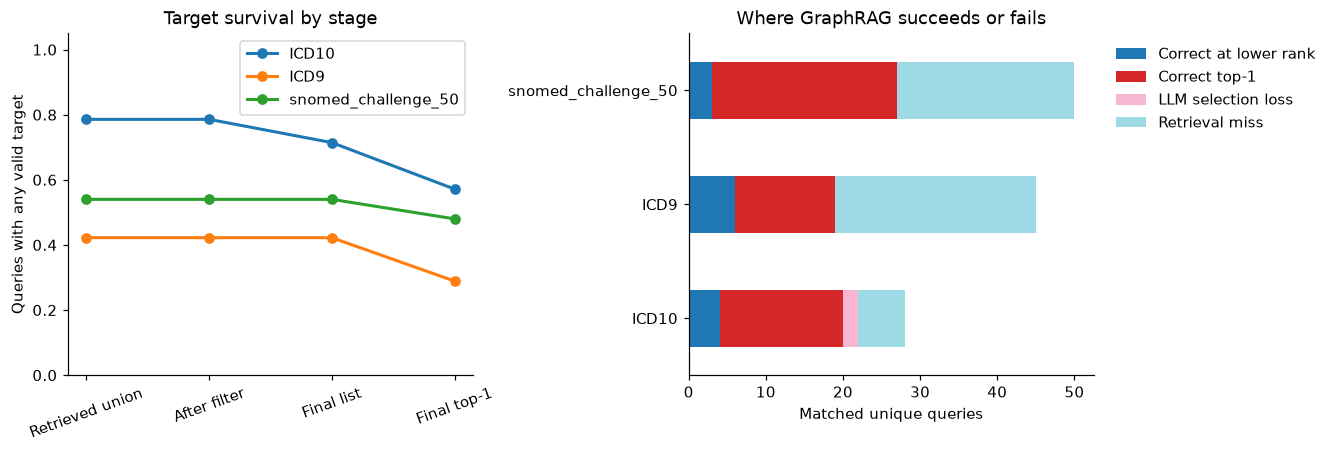

In [11]:
stages, outcomes, membership = evaluation.analyse_traces(trace_records)
evaluation.show_trace_diagnostics(stages, outcomes, membership, OUTPUT)

## 8. Walk through individual decisions

For each dataset, the cells below automatically select one correct first answer and one
failure, plus one outside-pool output if present (when available). To inspect any other query, set `EXAMPLE_QUERIES` to exact
diagnosis strings from `outcomes` and rerun the two example cells below.

Read the tables from top to bottom: input/targets → fused candidate scores and provenance
→ retained/excluded candidates → graph context supplied → final ranking and saved reasons.
Candidate `input_position` is its **fused-list position**, not a global score rank.
The position plot connects surviving candidates to their final ranks; it makes promotions
and omissions visible without claiming that input order was a sorted retrieval ranking.

In [12]:
# Leave these lists empty for automatically selected examples.
# To inspect a particular diagnosis, paste its exact text into the relevant list.
EXAMPLE_QUERIES = {"ICD9": [], "ICD10": [], "snomed_challenge_50": []}
examples = evaluation.select_examples(trace_records, EXAMPLE_QUERIES)

### ICD10 — oncology - chest tumors - primary lung cancer

1. Cleaned input: oncology chest tumors primary lung cancer
Ground truth (evaluation only; not supplied as labels to GraphRAG): 1259726005, 254622008, 254626006, 254632001, 254634000, 254635004, 707451005, 722528008, 93734005, 93880001
Log timestamp: 2026-10-03T17:56:17.822781 | line: 30
Candidates fused with Reciprocal Rank Fusion (RRF). Retrieval scores logged and copied by LLM.


**2–5. Retrieved candidates, RRF fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,rrf_score,base_rank,enriched_rank,sent_to_LLM,final_rank,is_target
0,1,1259727001,Primary non-small cell lung cancer (disorder),"[base, enriched]",1.000000,1.000000,1.000000,0.032787,1.0,1.0,True,2.0,False
1,2,93880001,Primary malignant neoplasm of lung (disorder),"[base, enriched]",1.000000,1.000000,1.000000,0.032258,2.0,2.0,True,1.0,True
2,3,1259754003,Primary squamous non-small cell lung cancer (disorder),"[base, enriched]",0.984204,0.984204,0.984204,0.031746,3.0,3.0,True,NaN,False
3,4,372110008,"Primary malignant neoplasm of lower lobe, bronchus or lung (disorder)","[base, enriched]",0.968886,0.981659,0.981659,0.031250,4.0,4.0,True,NaN,False
4,5,890529001,Primary malignant neoplasm of right lung (disorder),"[base, enriched]",0.951035,0.972502,0.972502,0.030303,6.0,6.0,True,4.0,False
5,6,890528009,Primary malignant neoplasm of left lung (disorder),"[base, enriched]",0.947885,0.966396,0.966396,0.029851,7.0,7.0,True,5.0,False
6,7,93734005,Primary malignant neoplasm of bronchus (disorder),[base],0.953962,NaN,0.953962,0.015385,5.0,NaN,True,NaN,True
7,8,415077006,History of primary malignant neoplasm of bronchus (situation),[enriched],NaN,0.979907,0.979907,0.015385,NaN,5.0,True,NaN,False
8,9,93986008,Primary malignant neoplasm of respiratory tract (disorder),[base],0.943877,NaN,0.943877,0.014706,8.0,NaN,True,NaN,False
9,10,1268348008,Primary small cell carcinoma of lung (disorder),[enriched],NaN,0.966360,0.966360,0.014706,NaN,8.0,True,3.0,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations (with retrieval scores)**

,rank,sctid,fsn,base_score,enriched_score,rrf_score,reason,is_target,in_LLM_pool
0,1,93880001,Primary malignant neoplasm of lung (disorder),1.000000,1.000000,0.032258,"This is the most accurate semantic match for 'primary lung cancer'. It captures the primary nature, the malignancy, and the specific organ (lung) without assuming a specific histological subtype (like NSCLC or SCLC) or laterality (left/right) which are not specified in the diagnosis string. It is the direct parent of the more specific candidates.",True,True
1,2,1259727001,Primary non-small cell lung cancer (disorder),1.000000,1.000000,0.032787,"A strong candidate as NSCLC is the most common form of primary lung cancer. However, it is more specific than the diagnosis string, which does not specify the cell type. It is ranked second because it is a valid interpretation but assumes histology not present in the text.",False,True
2,3,1268348008,Primary small cell carcinoma of lung (disorder),NaN,0.966360,0.014706,"Another specific histological subtype of primary lung cancer. Like NSCLC, it is a valid possibility but assumes a specific cell type (small cell) not mentioned in the diagnosis. Ranked lower than NSCLC generally due to lower prevalence, but semantically equivalent in specificity to the NSCLC candidate.",False,True
3,4,890529001,Primary malignant neoplasm of right lung (disorder),0.951035,0.972502,0.030303,"This candidate specifies the right lung. The diagnosis string does not specify laterality. While it is a primary malignant neoplasm of the lung, the addition of 'right' makes it more specific than the source text, making it a less ideal general match than the unspecified lung concept.",False,True
4,5,890528009,Primary malignant neoplasm of left lung (disorder),0.947885,0.966396,0.029851,"Similar to the right lung candidate, this specifies the left lung. It is a valid primary lung cancer but adds laterality information not present in the diagnosis string, making it less general than the unspecified lung concept.",False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,1.0,1.0,0.1,0.1,0.1,0.1,0.1


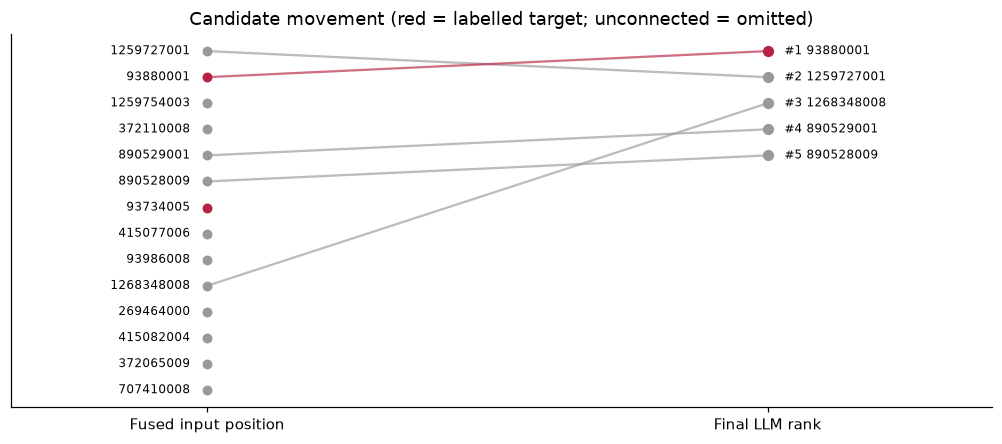

### ICD10 — oncology - skin, muscle and skeletal tumors - melanoma - nodular

1. Cleaned input: oncology skin, muscle and skeletal tumors melanoma nodular
Ground truth (evaluation only; not supplied as labels to GraphRAG): 1197324006, 254730000, 302837001, 307593001, 398696001, 403924008, 405843009, 424190005, 443493003, 94360002, 94459006
Log timestamp: 2026-10-03T17:59:33.375652 | line: 35
Candidates fused with Reciprocal Rank Fusion (RRF). Retrieval scores logged and copied by LLM.


**2–5. Retrieved candidates, RRF fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,rrf_score,base_rank,enriched_rank,sent_to_LLM,final_rank,is_target
0,1,254731001,Nodular malignant melanoma of skin (disorder),"[base, enriched]",1.000000,1.000000,1.000000,0.032787,1.0,1.0,True,1.0,False
1,2,2142002,Nodular melanoma (morphologic abnormality),"[base, enriched]",0.999926,1.000000,1.000000,0.032258,2.0,2.0,True,3.0,False
2,3,1259379002,Primary nodular malignant melanoma of skin (disorder),"[base, enriched]",0.978892,0.970318,0.978892,0.031746,3.0,3.0,True,2.0,False
3,4,253046007,Malignant myomatous tumor (morphologic abnormality),"[base, enriched]",0.968536,0.968608,0.968608,0.031250,4.0,4.0,True,NaN,False
4,5,372244006,Malignant melanoma (disorder),"[base, enriched]",0.966276,0.945425,0.966276,0.030536,5.0,6.0,True,4.0,False
5,6,126616000,Neoplasm of muscle (disorder),"[base, enriched]",0.953213,0.941879,0.953213,0.030077,6.0,7.0,True,NaN,False
6,7,302847003,Rhabdomyosarcoma (disorder),[enriched],NaN,0.955194,0.955194,0.015385,NaN,5.0,True,NaN,False
7,8,1162635006,Malignant melanoma (morphologic abnormality),[base],0.952122,NaN,0.952122,0.014925,7.0,NaN,True,5.0,False
8,9,363495004,Malignant neoplasm of muscle (disorder),[base],0.944539,NaN,0.944539,0.014706,8.0,NaN,True,NaN,False
9,10,254771006,Cutaneous leiomyosarcoma (disorder),[enriched],NaN,0.941400,0.941400,0.014706,NaN,8.0,True,NaN,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations (with retrieval scores)**

,rank,sctid,fsn,base_score,enriched_score,rrf_score,reason,is_target,in_LLM_pool
0,1,254731001,Nodular malignant melanoma of skin (disorder),1.000000,1.000000,0.032787,"Exact semantic match for 'melanoma - nodular' in the context of 'skin'. It is a disorder concept, which is the standard target for diagnosis normalization, and it captures the specific subtype (nodular) and site (skin).",False,True
1,2,1259379002,Primary nodular malignant melanoma of skin (disorder),0.978892,0.970318,0.031746,"Very strong match. It specifies 'Primary', which is clinically implied for a new diagnosis of skin melanoma unless metastasis is stated. It is a child of the top candidate, making it more specific but potentially over-specific if the source data doesn't explicitly distinguish primary vs secondary in this context. However, it is a valid disorder concept.",False,True
2,3,2142002,Nodular melanoma (morphologic abnormality),0.999926,1.000000,0.032258,"Matches the morphology and subtype exactly. However, it is a morphologic abnormality, not a disorder. In diagnosis normalization, disorder concepts are generally preferred over morphology concepts unless the context is purely pathological description. It lacks the explicit 'skin' site in the FSN, though it is a child of malignant melanoma.",False,True
3,4,372244006,Malignant melanoma (disorder),0.966276,0.945425,0.030536,"Correct disease entity but lacks the specific subtype 'nodular'. It is a parent concept. Used as a fallback if the specific subtype is not available, but here the specific subtype is available in higher-ranked candidates.",False,True
4,5,1162635006,Malignant melanoma (morphologic abnormality),0.952122,NaN,0.014925,Correct disease entity but lacks the specific subtype 'nodular' and is a morphologic abnormality rather than a disorder. Less specific and less appropriate for diagnosis coding than the disorder concepts above.,False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


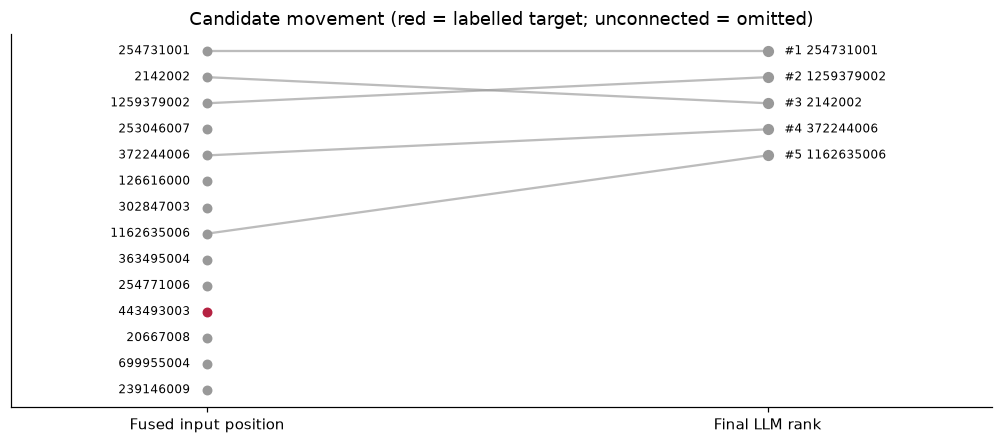

### ICD9 — cardiovascular - arrhythmias - atrial fibrillation

1. Cleaned input: cardiovascular arrhythmias atrial fibrillation
Ground truth (evaluation only; not supplied as labels to GraphRAG): 49436004
Log timestamp: 2026-10-03T17:05:35.812980 | line: 70
Candidates fused with Reciprocal Rank Fusion (RRF). Retrieval scores logged and copied by LLM.


**2–5. Retrieved candidates, RRF fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,rrf_score,base_rank,enriched_rank,sent_to_LLM,final_rank,is_target
0,1,49436004,Atrial fibrillation (disorder),"[base, enriched]",1.000000,1.000000,1.000000,0.032787,1.0,1.0,True,1.0,True
1,2,282825002,Paroxysmal atrial fibrillation (disorder),"[base, enriched]",0.984409,0.984409,0.984409,0.031281,2.0,6.0,True,2.0,False
2,3,233910005,Lone atrial fibrillation (disorder),"[base, enriched]",0.958240,0.998803,0.998803,0.030835,8.0,2.0,True,3.0,False
3,4,314208002,Rapid atrial fibrillation (disorder),"[base, enriched]",0.961935,0.985740,0.985740,0.030550,7.0,4.0,True,4.0,False
4,5,40593004,Fibrillation (disorder),"[base, enriched]",0.964228,0.982656,0.982656,0.029877,5.0,9.0,True,5.0,False
5,6,17366009,Atrial arrhythmia (disorder),[base],0.978566,NaN,0.978566,0.015873,3.0,NaN,True,NaN,False
6,7,300996004,Controlled atrial fibrillation (disorder),[enriched],NaN,0.989009,0.989009,0.015873,NaN,3.0,True,NaN,False
7,8,164889003,Electrocardiographic atrial fibrillation (finding),[base],0.967326,NaN,0.967326,0.015625,4.0,NaN,True,NaN,False
8,9,72654001,Supraventricular arrhythmia (disorder),[enriched],NaN,0.984567,0.984567,0.015385,NaN,5.0,True,NaN,False
9,10,233911009,Non-rheumatic atrial fibrillation (disorder),[base],0.962684,NaN,0.962684,0.015152,6.0,NaN,True,NaN,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations (with retrieval scores)**

,rank,sctid,fsn,base_score,enriched_score,rrf_score,reason,is_target,in_LLM_pool
0,1,49436004,Atrial fibrillation (disorder),1.000000,1.000000,0.032787,"Exact semantic match to the diagnosis string 'atrial fibrillation'. It is the parent concept for all specific subtypes (paroxysmal, persistent, etc.) and represents the general condition without assuming specific clinical course or etiology.",True,True
1,2,282825002,Paroxysmal atrial fibrillation (disorder),0.984409,0.984409,0.031281,"A specific subtype of atrial fibrillation. While the diagnosis string does not specify 'paroxysmal', it is a common clinical presentation and a direct child of the main concept. Ranked second as a plausible specific instance if the general term was used loosely, but less precise than the parent.",False,True
2,3,233910005,Lone atrial fibrillation (disorder),0.958240,0.998803,0.030835,"A specific subtype defined by the absence of structural heart disease. The diagnosis string does not provide information about the patient's cardiac structure, so this is a less likely match than the general term, but still a valid specific form of AF.",False,True
3,4,314208002,Rapid atrial fibrillation (disorder),0.961935,0.985740,0.030550,"A specific subtype characterized by ventricular rate. The diagnosis string does not mention rate control or rapid response, making this a less precise match than the general term, but it is a direct child and clinically relevant.",False,True
4,5,40593004,Fibrillation (disorder),0.964228,0.982656,0.029877,"A broader parent concept that includes both atrial and ventricular fibrillation. It is less specific than 'Atrial fibrillation (disorder)' and therefore ranked lower, as the diagnosis explicitly specifies 'atrial'.",False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


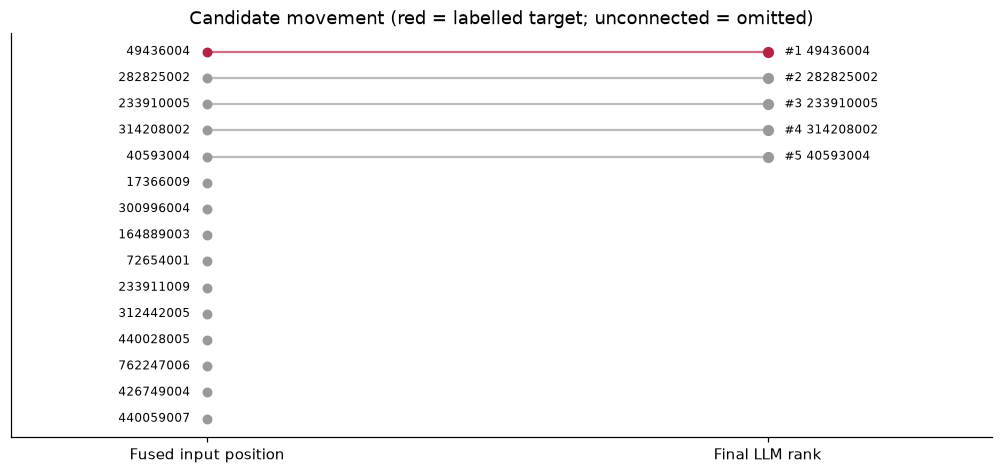

### ICD9 — cardiovascular - arrhythmias - ventricular tachycardia

1. Cleaned input: cardiovascular arrhythmias ventricular tachycardia
Ground truth (evaluation only; not supplied as labels to GraphRAG): 66657009
Log timestamp: 2026-10-03T17:05:00.020291 | line: 69
Candidates fused with Reciprocal Rank Fusion (RRF). Retrieval scores logged and copied by LLM.


**2–5. Retrieved candidates, RRF fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,rrf_score,base_rank,enriched_rank,sent_to_LLM,final_rank,is_target
0,1,6624005,Ventricular tachyarrhythmia (disorder),"[base, enriched]",1.000000,1.000000,1.000000,0.032787,1.0,1.0,True,2.0,False
1,2,25569003,Ventricular tachycardia (disorder),"[base, enriched]",1.000000,1.000000,1.000000,0.032258,2.0,2.0,True,1.0,False
2,3,164895002,Electrocardiographic ventricular tachycardia (finding),"[base, enriched]",0.990198,0.990198,0.990198,0.031498,3.0,4.0,True,3.0,False
3,4,708124001,Recurrent ventricular tachycardia (disorder),"[base, enriched]",0.967018,0.991942,0.991942,0.031258,5.0,3.0,True,5.0,False
4,5,426525004,Sustained ventricular tachycardia (disorder),"[base, enriched]",0.969127,0.982520,0.982520,0.031010,4.0,5.0,True,4.0,False
5,6,233907003,Induced ventricular tachycardia (disorder),"[base, enriched]",0.947786,0.961441,0.961441,0.029412,8.0,8.0,True,NaN,False
6,7,444658006,Nonsustained ventricular tachycardia (disorder),"[base, enriched]",0.953232,0.958123,0.958123,0.029211,7.0,10.0,True,NaN,False
7,8,44103008,Ventricular arrhythmia (disorder),[base],0.953321,NaN,0.953321,0.015152,6.0,NaN,True,NaN,False
8,9,429046004,History of sustained ventricular tachycardia (situation),[enriched],NaN,0.974613,0.974613,0.015152,NaN,6.0,True,NaN,False
9,10,233906007,Familial ventricular tachycardia (disorder),[enriched],NaN,0.967538,0.967538,0.014925,NaN,7.0,True,NaN,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations (with retrieval scores)**

,rank,sctid,fsn,base_score,enriched_score,rrf_score,reason,is_target,in_LLM_pool
0,1,25569003,Ventricular tachycardia (disorder),1.000000,1.000000,0.032258,"Exact semantic match to the diagnosis string 'ventricular tachycardia'. It is the parent concept for specific types (sustained, nonsustained, etc.) and represents the general disorder without adding unmentioned qualifiers.",False,True
1,2,6624005,Ventricular tachyarrhythmia (disorder),1.000000,1.000000,0.032787,"Highly relevant as it is a direct synonym/related concept in the hierarchy (parent of VT in some views, child in others depending on branch, but semantically very close). However, 'tachycardia' is the specific term in the diagnosis, making 25569003 the primary choice. This is a strong alternative if the system prefers the broader 'tachyarrhythmia' label, but 25569003 is the exact FSN match.",False,True
2,3,164895002,Electrocardiographic ventricular tachycardia (finding),0.990198,0.990198,0.031498,"Represents the ECG finding of ventricular tachycardia. While the diagnosis is a disorder, this is a common normalization target for clinical findings. It is less preferred than the disorder concept for a general diagnosis but is a valid clinical interpretation.",False,True
3,4,426525004,Sustained ventricular tachycardia (disorder),0.969127,0.982520,0.031010,"A specific subtype of ventricular tachycardia. The diagnosis string does not specify 'sustained', so this is a more specific concept than the general diagnosis. It is ranked lower because it adds a qualifier not present in the source text.",False,True
4,5,708124001,Recurrent ventricular tachycardia (disorder),0.967018,0.991942,0.031258,Another specific subtype implying a clinical course (recurrence) not stated in the diagnosis string. Ranked lower than the general disorder and sustained VT due to the added specificity.,False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


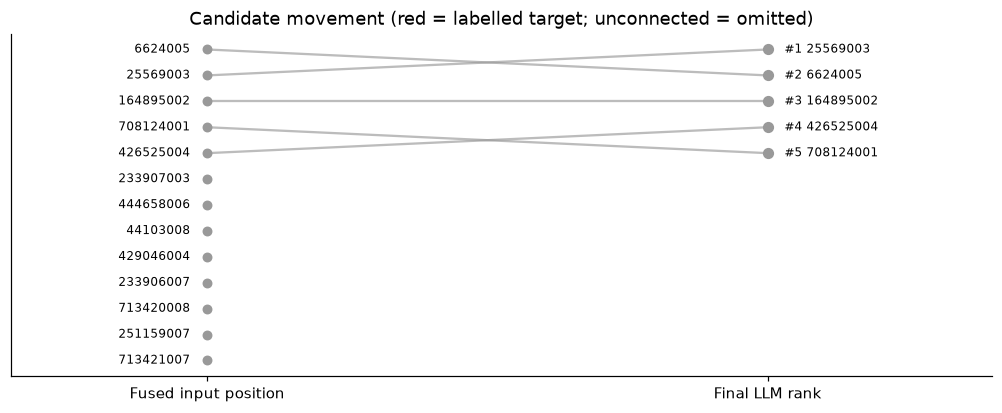

### snomed_challenge_50 — teaching - teaching

1. Cleaned input: teaching teaching
Ground truth (evaluation only; not supplied as labels to GraphRAG): 311401005, 409073007
Log timestamp: 2026-10-04T16:45:54.326294 | line: 2
Candidates fused with Reciprocal Rank Fusion (RRF). Retrieval scores logged and copied by LLM.


**2–5. Retrieved candidates, RRF fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,rrf_score,base_rank,enriched_rank,sent_to_LLM,final_rank,is_target
0,1,302311007,Teaching principal (occupation),"[base, enriched]",1.000000,1.000000,1.000000,0.032787,1,1,True,5.0,False
1,2,425689005,Education - action (qualifier value),"[base, enriched]",1.000000,1.000000,1.000000,0.032258,2,2,True,2.0,False
2,3,409073007,Education (procedure),"[base, enriched]",0.997902,0.997902,0.997902,0.031746,3,3,True,1.0,True
3,4,158980006,Dental practitioner - teaching (occupation),"[base, enriched]",0.976577,0.976577,0.976577,0.031250,4,4,True,NaN,False
4,5,158975002,Medical practitioner - teaching (occupation),"[base, enriched]",0.976577,0.976577,0.976577,0.030769,5,5,True,NaN,False
5,6,870373009,Teaching aid specialist (occupation),"[base, enriched]",0.976577,0.976577,0.976577,0.030303,6,6,True,NaN,False
6,7,469076007,Endoscopic teaching attachment (physical object),"[base, enriched]",0.954225,0.954225,0.954225,0.029851,7,7,True,NaN,False
7,8,405232007,Client satisfaction: teaching (observable entity),"[base, enriched]",0.954225,0.954225,0.954225,0.029412,8,8,True,NaN,False
8,9,311401005,Patient education (regime/therapy),"[base, enriched]",0.942780,0.942780,0.942780,0.028986,9,9,True,3.0,True
9,10,2458006,Educational therapy (regime/therapy),"[base, enriched]",0.939912,0.939912,0.939912,0.028571,10,10,True,4.0,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations (with retrieval scores)**

,rank,sctid,fsn,base_score,enriched_score,rrf_score,reason,is_target,in_LLM_pool
0,1,409073007,Education (procedure),0.997902,0.997902,0.031746,"The diagnosis string 'teaching teaching' is a repetition of the word 'teaching'. In a clinical context, this most likely refers to the act of teaching or patient education. 'Education (procedure)' is the standard SNOMED CT concept for this activity, with 'Teaching' listed as a synonym in its description. It is the most semantically appropriate match for the action described.",True,True
1,2,425689005,Education - action (qualifier value),1.000000,1.000000,0.032258,"This concept explicitly lists 'Teaching - action' as a synonym. It represents the action of teaching/education. While it is a qualifier value rather than a procedure, it is a very strong semantic match for the word 'teaching' as an action.",False,True
2,3,311401005,Patient education (regime/therapy),0.942780,0.942780,0.028986,"This is a specific type of education procedure focused on patients. It is a child of 'Education (procedure)'. It is a plausible interpretation if the context implies clinical patient education, which is common in medical records.",True,True
3,4,2458006,Educational therapy (regime/therapy),0.939912,0.939912,0.028571,This concept refers to therapy involving education. It is related to the act of teaching but is more specific to a therapeutic context. It is less likely than general education but still relevant.,False,True
4,5,302311007,Teaching principal (occupation),1.000000,1.000000,0.032787,"This is an occupation concept. While it contains the word 'Teaching', it refers to a specific job role (principal) rather than the act of teaching. It is included as a lower-ranked candidate because it matches the keyword but is semantically distinct from the likely intended meaning of the action.",False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,1.0,1.0,0.5,0.5,1.0,1.0,1.0


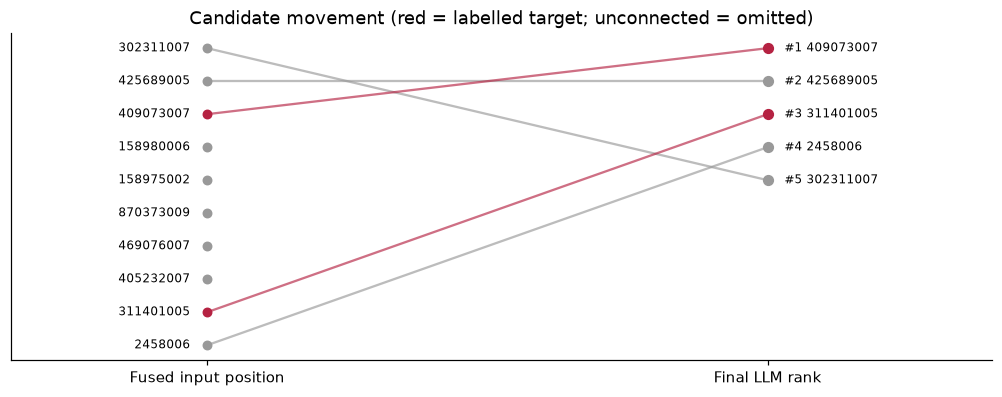

### snomed_challenge_50 — Phos - Phos-3.2

1. Cleaned input: Phos Phos 3.2
Ground truth (evaluation only; not supplied as labels to GraphRAG): 104868000
Log timestamp: 2026-10-04T16:45:24.420282 | line: 1
Candidates fused with Reciprocal Rank Fusion (RRF). Retrieval scores logged and copied by LLM.


**2–5. Retrieved candidates, RRF fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,rrf_score,base_rank,enriched_rank,sent_to_LLM,final_rank,is_target
0,1,1193871005,Product containing precisely hypromellose 3.2 milligram/1 milliliter conventional release eye drops (clini...,"[base, enriched]",1.000000,1.000000,1.000000,0.032787,1,1,True,NaN,False
1,2,785107005,Product containing precisely hypromellose 3.2 milligram/1 milliliter conventional release eye solution (cl...,"[base, enriched]",1.000000,1.000000,1.000000,0.032258,2,2,True,NaN,False
2,3,259296007,Phosphate (substance),"[base, enriched]",1.000000,1.000000,1.000000,0.031746,3,3,True,1.0,False
3,4,7156005,Phosphorus isotope (substance),"[base, enriched]",0.990791,0.990791,0.990791,0.031250,4,4,True,4.0,False
4,5,30820000,Phosphorus (substance),"[base, enriched]",0.983465,0.983465,0.983465,0.030769,5,5,True,3.0,False
5,6,102663005,Triosephosphate (substance),"[base, enriched]",0.974844,0.974844,0.974844,0.030303,6,6,True,NaN,False
6,7,87802005,Phosphorus-33 (substance),"[base, enriched]",0.974666,0.974666,0.974666,0.029851,7,7,True,5.0,False
7,8,264726001,ph0 (qualifier value),"[base, enriched]",0.967624,0.967624,0.967624,0.029412,8,8,True,NaN,False
8,9,51369005,Phosmet (substance),"[base, enriched]",0.964685,0.964685,0.964685,0.028986,9,9,True,NaN,False
9,10,117634005,Inorganic phosphorus (substance),"[base, enriched]",0.962253,0.962253,0.962253,0.028571,10,10,True,2.0,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations (with retrieval scores)**

,rank,sctid,fsn,base_score,enriched_score,rrf_score,reason,is_target,in_LLM_pool
0,1,259296007,Phosphate (substance),1.000000,1.000000,0.031746,"The diagnosis 'Phos Phos 3.2' is a standard abbreviation for a serum Phosphate level of 3.2. This concept represents the substance being measured. Although it is a substance and not a finding, it is the most semantically relevant candidate among the options provided, as the other candidates are unrelated drugs or isotopes.",False,True
1,2,117634005,Inorganic phosphorus (substance),0.962253,0.962253,0.028571,"Serum phosphate measurements typically quantify inorganic phosphorus. This is a specific child of Phosphorus and a more precise descriptor of the analyte in a clinical chemistry context than the generic parent, though the parent is often used for the general test name.",False,True
2,3,30820000,Phosphorus (substance),0.983465,0.983465,0.030769,"This is the elemental form of phosphorus. While 'Phos' can refer to phosphorus, in the context of a lab value '3.2', it refers to the phosphate ion. However, it is a valid related substance and ranks higher than unrelated isotopes or drugs.",False,True
3,4,7156005,Phosphorus isotope (substance),0.990791,0.990791,0.031250,This is a specific type of phosphorus substance. It is semantically related to the keyword 'Phos' but is not the standard analyte for a routine 'Phos' lab test. It is ranked lower than the general substance concepts.,False,True
4,5,87802005,Phosphorus-33 (substance),0.974666,0.974666,0.029851,"This is a specific radioisotope. It is a false positive match based on the string 'Phos' and the number '3' (from 3.2), but it is clinically irrelevant to a standard phosphate level. It is included only to fill the top 5 slots with the most relevant remaining substance concepts.",False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


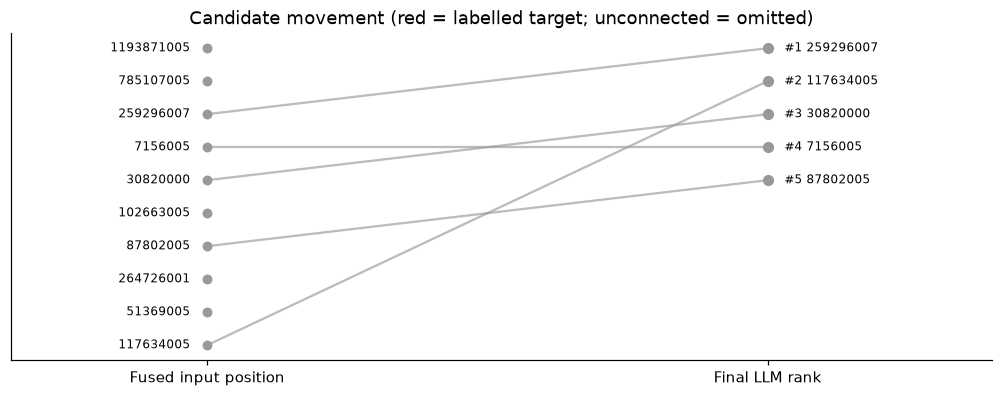

In [13]:
for trace in examples:
    evaluation.explain_trace(trace, ks=KS, mrr_depth=MRR_DEPTH, output_dir=OUTPUT)

## 9. Inspect errors and interpret the comparison

Use the outcome table to select additional examples. A correct target absent from the
retrieved union cannot be recovered by a candidate-constrained reranker; a target lost
after filtering points to a different issue than one passed to the LLM but not selected.
Check outside-pool outputs before making that interpretation.

Compare methods **within each dataset first**. ICD10's larger valid-target sets make its
recall scale different from ICD9's, even when Top-1 Accuracy is high. Also compare the
two averaging views: differences indicate sensitivity to repeated queries. The baseline
names describe their pipeline inputs, not a controlled ablation of GraphRAG. In particular,
these results alone cannot attribute a gain specifically to graph context or the LLM;
that would require matched retrieval-only and no-graph-context experiments.

In [14]:
if not outcomes.empty:
    errors = outcomes[outcomes.outcome.ne("Correct top-1")]
    display(errors.reset_index(drop=True))

evaluation.print_comparison_summary(scores, KS, MRR_DEPTH, PRIMARY_VIEW)

,dataset,query_key,diagnosis_text,outcome
0,ICD10,"(oncology - skin, muscle and skeletal tumors - melanoma - nodular, C43.9)","oncology - skin, muscle and skeletal tumors - melanoma - nodular",LLM selection loss
1,ICD10,"(oncology - GI tumors - anal CA, C18.0)",oncology - GI tumors - anal CA,Retrieval miss
2,ICD10,"(oncology - GU tumors - renal cell CA, C64.9)",oncology - GU tumors - renal cell CA,Retrieval miss
3,ICD10,"(infectious diseases - skin, bone and joint infections - shingles, B02.9)","infectious diseases - skin, bone and joint infections - shingles",LLM selection loss
4,ICD10,"(oncology - chest tumors - primary lung cancer - small cell CA, C34.90)",oncology - chest tumors - primary lung cancer - small cell CA,Retrieval miss
...,...,...,...,...
65,snomed_challenge_50,serosanguinous drainage - serosanguinous drainage.,serosanguinous drainage - serosanguinous drainage.,Retrieval miss
66,snomed_challenge_50,CXR - CXR-,CXR - CXR-,Retrieval miss
67,snomed_challenge_50,"DT - DTs,","DT - DTs,",Retrieval miss
68,snomed_challenge_50,OM1 - OM1.,OM1 - OM1.,Retrieval miss


ICD10 (unique query):
  Top-1 Accuracy: GraphRAG 0.5862; best baseline AI context + BioLORD 0.4828; difference +0.1034
  MRR@5: GraphRAG 0.6247; best baseline AI context + BioLORD 0.5805; difference +0.0443
  Recall@5: GraphRAG 0.1671; best baseline AI context + BioLORD 0.1201; difference +0.0470
ICD9 (unique query):
  Top-1 Accuracy: GraphRAG 0.3265; best baseline SapBERT 0.2449; difference +0.0816
  MRR@5: GraphRAG 0.3844; best baseline SapBERT 0.2993; difference +0.0850
  Recall@5: GraphRAG 0.4694; best baseline BM25 0.3878; difference +0.0816
snomed_challenge_50 (unique query):
  Top-1 Accuracy: GraphRAG 0.4800; best baseline SapBERT 0.4000; difference +0.0800
  MRR@5: GraphRAG 0.5067; best baseline SapBERT 0.4533; difference +0.0533
  Recall@5: GraphRAG 0.5400; best baseline SapBERT 0.5000; difference +0.0400


## 10. Save tables and reproducibility information

Exports go to a separate evaluation directory. The manifest records input hashes,
evaluation settings, package versions, and hashes of the current GraphRAG source. Source
hashes describe the code available during evaluation; historical model/run settings cannot
be recovered from these artifacts. Existing pipeline outputs and the poster notebook are
left intact. Rerunning this notebook refreshes its own named exports.

In [15]:
exports = {
    "dataset_audit": audit,
    "prediction_coverage": coverage,
    "method_scores": scores,
    "graphrag_minus_baselines": deltas,
    "per_row_scores": per_row,
    "per_query_scores": per_query,
    "trace_coverage": trace_coverage,
    "graphrag_stages": stages,
    "graphrag_outcomes": outcomes,
    "candidate_membership": membership,
}
evaluation.export_evaluation(
    exports, SPECS, ROOT, OUTPUT, ks=KS, mrr_depth=MRR_DEPTH, view=PRIMARY_VIEW,
)

Saved 10 tables, PNG/SVG figures, worked-example evidence, and manifest to C:\repos\concept-normalisation\data\output\graphrag_baseline_evaluation
